<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 111.7 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 167.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 161.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 180.5 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-01-22 00:25:49--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  72.6MB/s    in 2.1s    

2026-01-22 00:25:51 (72.6 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



In [4]:
!pip install seaborn

In [5]:
# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [36]:
# Load the data
df = pd.read_csv("survey-data.csv")

In [37]:
# Display the first few rows to understand the structure of the data
#df.head()

### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



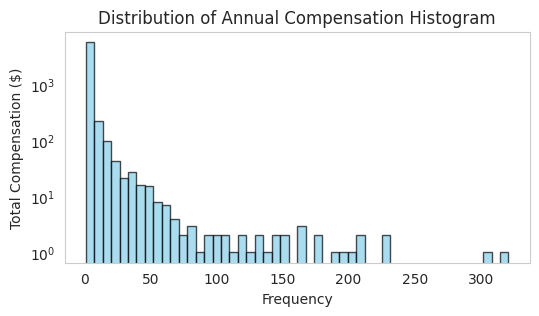

In [38]:
plt.figure(figsize=(6,3))
df['ConvertedCompYearly'].value_counts().plot(kind='hist', bins=50, logy=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Annual Compensation Histogram')
plt.ylabel('Total Compensation ($)')
plt.xlabel('Frequency')
plt.grid(False)
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



<Axes: ylabel='Age'>

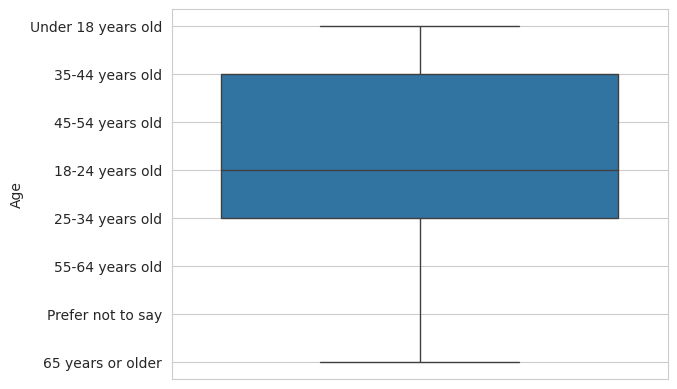

In [39]:
## Write your code here
sns.boxplot(data=df, y='Age', legend=False)

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



In [40]:
df_age_ccyr = df[['Age','ConvertedCompYearly']]

In [41]:
# Define the numeric mapping (midpoints are often used for regression)
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None  # This will be dropped for regression
}

# Create a new numeric column
df_age_ccyr['Age_Numeric'] = df_age_ccyr['Age'].map(age_mapping)

In [42]:
df_age_ccyr['ConvertedCompYearly'] = pd.to_numeric(df_age_ccyr['ConvertedCompYearly'], errors='coerce')

In [43]:
# Keep data between the 1st and 99th percentile
lower_limit = df_age_ccyr['ConvertedCompYearly'].quantile(0.01)
upper_limit = df_age_ccyr['ConvertedCompYearly'].quantile(0.99)

df_age_ccyr = df_age_ccyr[(df_age_ccyr['ConvertedCompYearly'] > lower_limit) & (df_age_ccyr['ConvertedCompYearly'] < upper_limit)]

In [44]:
df_AgeCcyr = df_age_ccyr.dropna(subset=['Age_Numeric', 'ConvertedCompYearly'])
#df_AgeCcyr.head()

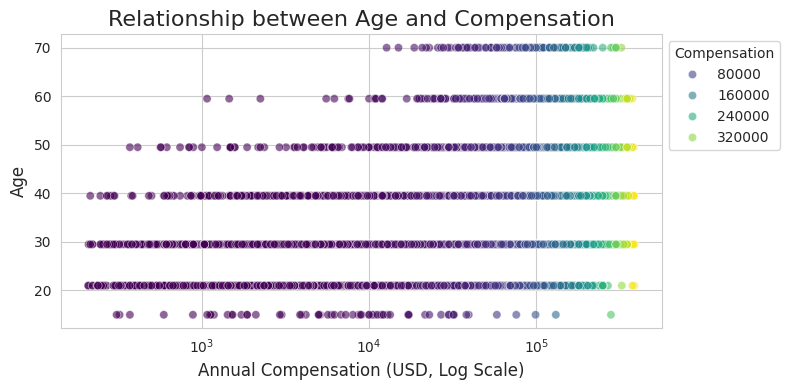

In [45]:
## Write your code here

# Visualization Code
plt.figure(figsize=(8, 4))
sns.set_style("whitegrid")
# Create the scatter plot
scatter = sns.scatterplot(data=df_AgeCcyr, x='ConvertedCompYearly', y='Age_Numeric', hue='ConvertedCompYearly', alpha=0.6, palette='viridis')
# Apply log scale to X-axis if compensation has extreme outliers
plt.xscale('log')
# Formatting
plt.title('Relationship between Age and Compensation', fontsize=16)
plt.xlabel('Annual Compensation (USD, Log Scale)', fontsize=12)
plt.ylabel('Age', fontsize=12)
# Legend with 2 columns as requested
plt.legend(title='Compensation', bbox_to_anchor=(1, 1), loc='upper left', ncol=1)

plt.tight_layout()
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size

Explore how compensation and job satisfaction are related, with age as the bubble size.

In [46]:
## Write your code here
df_AgeCcyr['JobSatPoints_6'] = df['JobSatPoints_6']

In [47]:
df_AgeCcyr['JobSatPoints_6'] = pd.to_numeric(df_AgeCcyr['JobSatPoints_6'], errors = 'coerce')

In [48]:
df_AgeCcyr = df_AgeCcyr.dropna(subset=['JobSatPoints_6'])

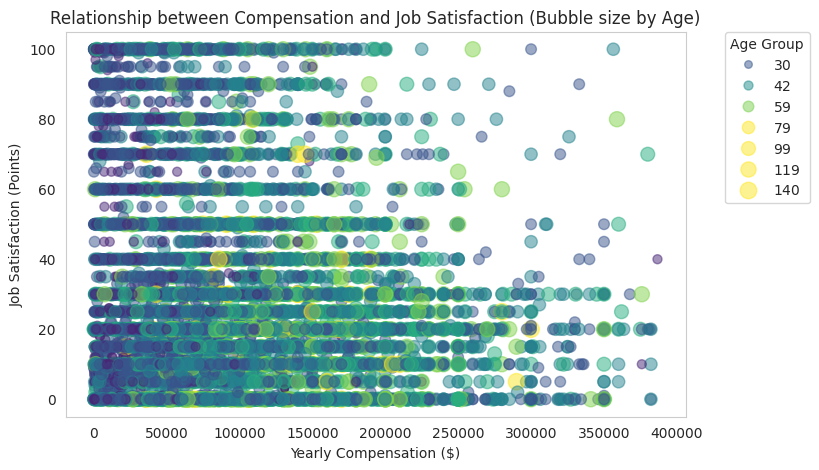

In [55]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    df_AgeCcyr['ConvertedCompYearly'],
    df_AgeCcyr['JobSatPoints_6'],
    s=df_AgeCcyr['Age_Numeric']*2, # Scale age for better visibility of bubble sizes
    alpha=0.5,
    c=df_AgeCcyr['Age_Numeric'], # Optional: color by age as well
    cmap='viridis'
)
# Add labels and title
plt.title('Relationship between Compensation and Job Satisfaction (Bubble size by Age)')
plt.xlabel('Yearly Compensation ($)')
plt.ylabel('Job Satisfaction (Points)')
# Add a legend for size
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
for handle, label in zip(handles, labels):
    # Parse the numeric value from the label (e.g., '40' from the text)
    val = float(label.replace('$\\mathdefault{', '').replace('}$', ''))
    color = scatter.cmap(scatter.norm(val))
    handle.set_color(color)
    
plt.legend(handles, labels, loc="upper right", title="Age Group", facecolor='inherit', bbox_to_anchor=(1.2, 1), borderaxespad=0.)
plt.grid(False)
plt.show() # Use plt.show() to display the plot

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution

Visualize the distribution of respondents’ primary roles to understand their professional focus.

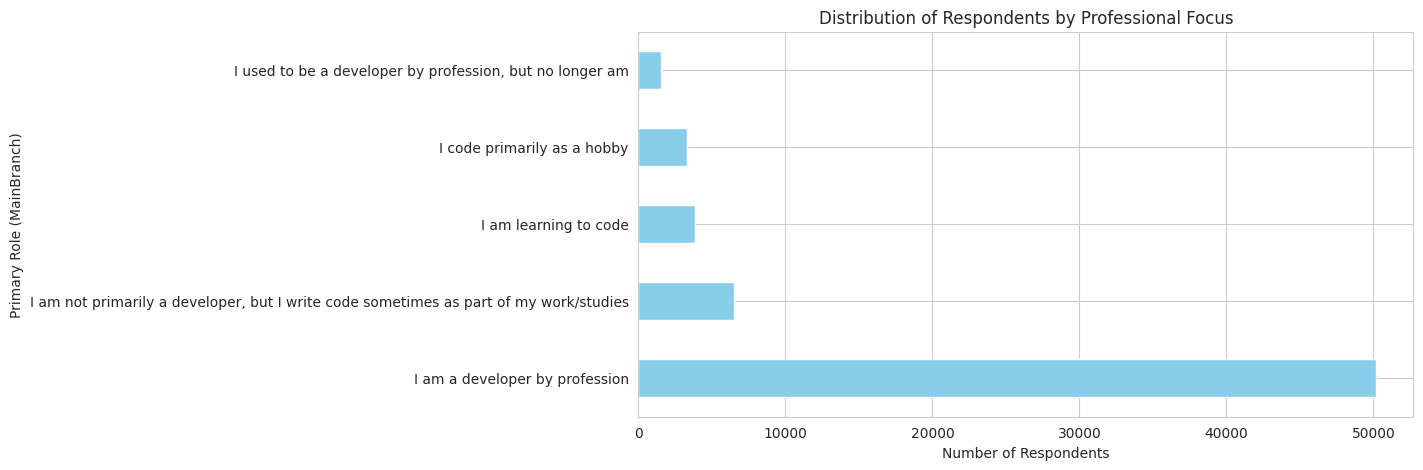

In [106]:
# 1. Count the frequency of each unique value in the 'MainBranch' column
# value_counts() returns counts in descending order by default
branch_counts = df['MainBranch'].value_counts()
# 2. Plot as a horizontal bar chart
# 'barh' creates a horizontal orientation, which is better for long category names
branch_counts.plot(kind='barh', figsize=(10, 5), color='skyblue')
# 3. Add labels and title for professional visualization
plt.xlabel('Number of Respondents')
plt.ylabel('Primary Role (MainBranch)')
plt.title('Distribution of Respondents by Professional Focus')
# 4. Optional: Invert the y-axis to show the highest frequency at the top
#plt.gca().invert_yaxis()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



In [59]:
# 1. Clean and expand the multi-value column
# Split strings by ';' into lists and 'explode' them so each language gets its own row
languages_desired = df['LanguageWantToWorkWith'].str.split(';').explode()

In [60]:
# 2. Identify the top 5 most frequent languages
top_5_languages = languages_desired.value_counts().head(5)

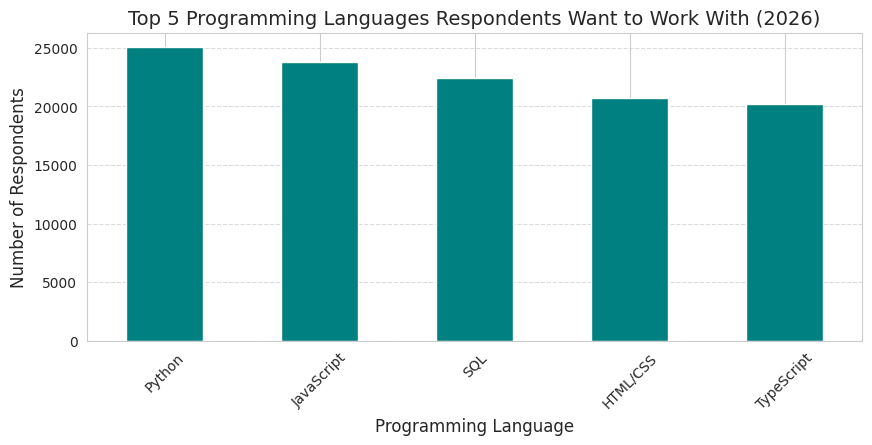

In [107]:
# 3. Visualize as a vertical bar chart
plt.figure(figsize=(10, 4))
top_5_languages.plot(kind='bar', color='teal')
# 4. Add professional formatting
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.title('Top 5 Programming Languages Respondents Want to Work With (2026)', fontsize=14)
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group

Compare job satisfaction metrics across different age groups with a stacked bar chart.

In [62]:
# 1. Group by Age and calculate the median for the specific JobSat columns
job_sat_medians = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()

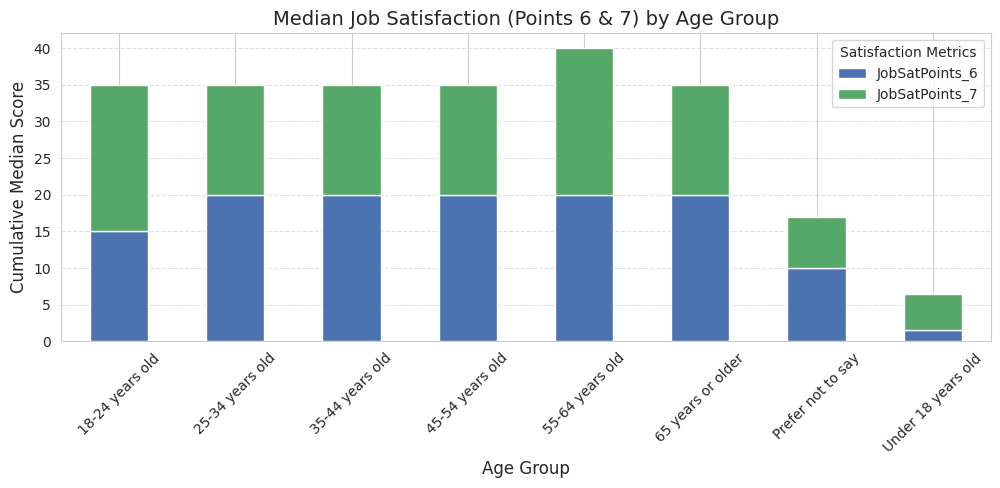

In [66]:
# 2. Plot the results as a stacked bar chart
job_sat_medians.plot(kind='bar', stacked=True, figsize=(12, 4), color=['#4C72B0', '#55A868'])
# 3. Add professional formatting and labels
plt.title('Median Job Satisfaction (Points 6 & 7) by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Cumulative Median Score', fontsize=12)
plt.legend(['JobSatPoints_6', 'JobSatPoints_7'], title='Satisfaction Metrics')
plt.xticks(rotation=45)  # Rotates age group labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



In [67]:
# 1. Split the multi-select strings into individual lists
# 2. 'explode' the lists so each database has its own row for counting
db_series = df['DatabaseHaveWorkedWith'].str.split(';').explode()

In [68]:
# 3. Calculate frequency and select the top results (e.g., top 10)
db_counts = db_series.value_counts().head(10)

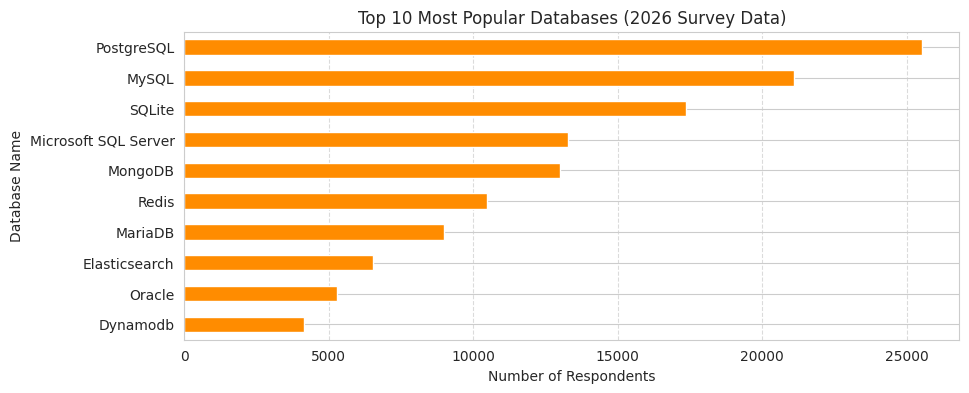

In [70]:
# 4. Create a horizontal bar chart
# Horizontal is preferred for databases due to longer names (e.g., Microsoft SQL Server)
plt.figure(figsize=(10, 4))
db_counts.plot(kind='barh', color='darkorange')
# 5. Professional formatting
plt.xlabel('Number of Respondents')
plt.ylabel('Database Name')
plt.title('Top 10 Most Popular Databases (2026 Survey Data)')
plt.gca().invert_yaxis()  # Ensure the most popular is at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



In [71]:
# 1. Group by Age and calculate the median compensation
# 'ConvertedCompYearly' is the standard column for annual salary in developer surveys
comp_by_age = df.groupby('Age')['ConvertedCompYearly'].median().reset_index()

In [72]:
# 2. Filter for specific relevant age ranges if needed (e.g., standard working ages)
# This step ensures the chart is not cluttered with outlier age groups
relevant_ages = ['18-24 years old', '25-34 years old', '35-44 years old', 
                 '45-54 years old', '55-64 years old', '65 years or older']
comp_by_age = comp_by_age[comp_by_age['Age'].isin(relevant_ages)]

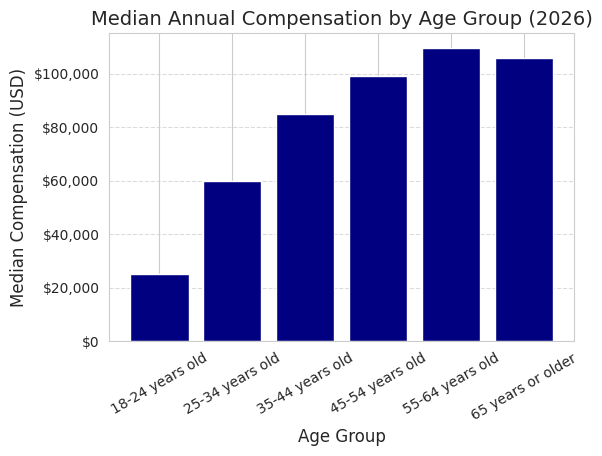

In [75]:
## Write your code here
# 3. Create the bar chart
plt.figure(figsize=(6,4))
plt.bar(comp_by_age['Age'], comp_by_age['ConvertedCompYearly'], color='navy')
# 4. Add professional formatting
plt.title('Median Annual Compensation by Age Group (2026)', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Compensation (USD)', fontsize=12)
plt.xticks(rotation=30)  # Rotates labels for better fit
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Format y-axis with dollar signs and commas for readability
from matplotlib.ticker import StrMethodFormatter
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



In [102]:
# 1. Count respondents per country and select the top 10
# This identifies the most represented regions in the survey
country_counts = df['Country'].value_counts().head(10)

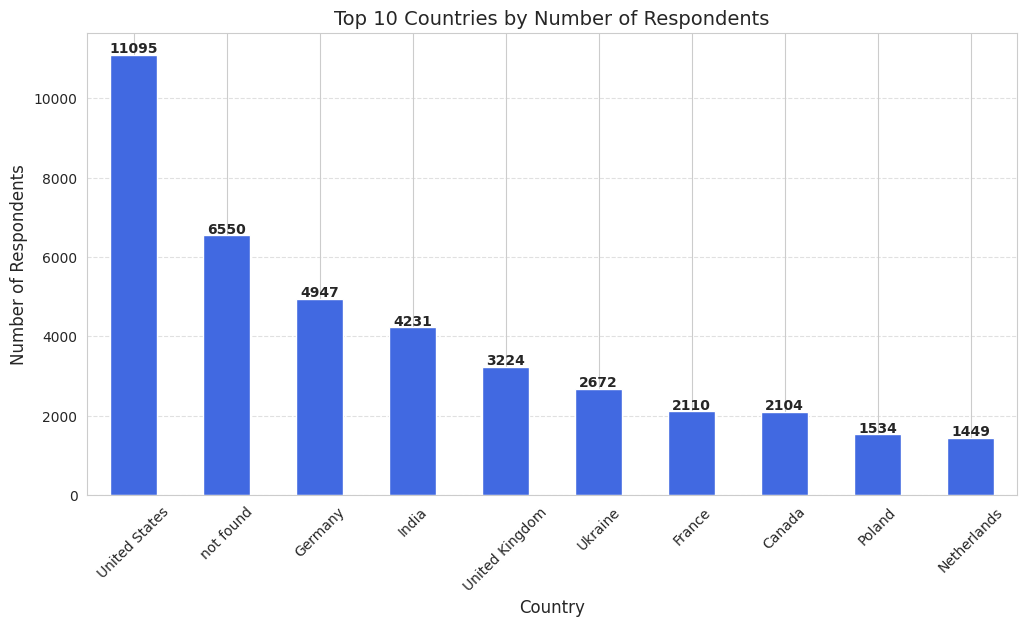

In [105]:
# 2. Create the bar chart
plt.figure(figsize=(12, 6))
country_counts.plot(kind='bar', color='royalblue')
# 3. Add professional labels and formatting
plt.title('Top 10 Countries by Number of Respondents', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45)  # Rotates country names for better readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 4. Optional: Add data labels on top of each bar for precision
for i, v in enumerate(country_counts):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
